# Weight Change Analysis Across Intervention Phases

This notebook analyzes weight changes across the two intervention phases 
of the AI4Food crossover study — traditional monitoring and digital monitoring — 
for both participant groups.

## Study Design Reminder
- **Group 1:** Traditional phase first (V0→V2), then Digital phase (V2→V3)
- **Group 2:** Digital phase first (V0→V2), then Traditional phase (V2→V3)

## Research Question
Do participants lose significantly more weight during the digital monitoring 
phase compared to the traditional phase? And does the order of intervention 
matter?

## Key Finding
Digital monitoring produced significantly greater weight loss than traditional 
monitoring (-1.55 kg vs -0.75 kg, p = 0.0004), regardless of intervention order.

Summary Statistics:
                               count  mean   std  min   25%   50%   75%  max
Interval                                                                    
Group 1\nDigital\n(V2–V3)       46.0 -1.24  1.22 -4.1 -2.07 -0.95 -0.30  1.0
Group 1\nTraditional\n(V0–V2)   46.0 -1.03  1.49 -4.2 -2.00 -1.15 -0.23  3.2
Group 2\nDigital\n(V0–V2)       46.0 -1.51  1.08 -3.7 -2.15 -1.55 -0.83  1.4
Group 2\nTraditional\n(V2–V3)   46.0 -0.79  1.11 -3.5 -1.30 -0.75 -0.10  1.9

Statistical Comparisons:
  Traditional vs Digital (V0–V2): p = 0.0800 (ns)
  Digital vs Traditional (V2–V3): p = 0.0687 (ns)
  Group 1: Traditional vs Digital: p = 0.4199 (ns)
  Group 2: Digital vs Traditional: p = 0.0004 (***)


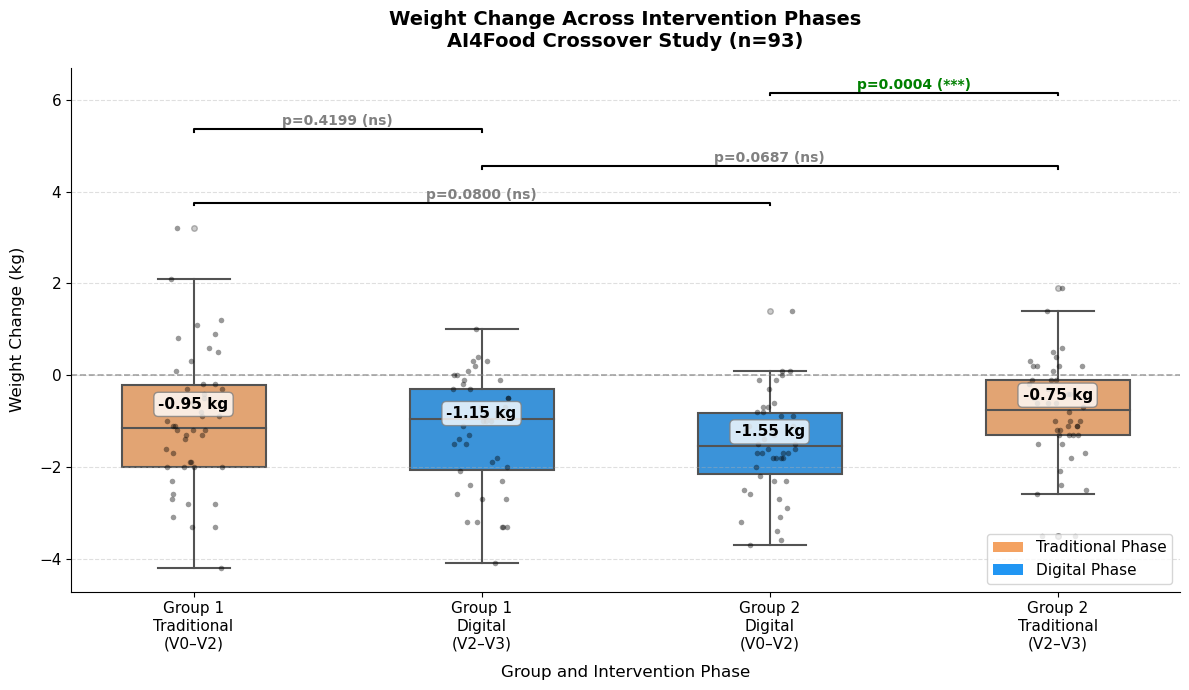

Figure saved to figures/weight_change_comparison.png


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, ttest_rel, wilcoxon
import numpy as np
import os

# LOAD DATA

def load_weight_data(base_path):
    """
    Load weight change data for both groups and intervals.
    
    Parameters:
    -----------
    base_path : str — path to weight_change folder
    
    Returns:
    --------
    dict of DataFrames with computed weight changes
    """
    files = {
        'g1_v0_v2': f"{base_path}/grp1/group1_weight_v0_v2.csv",
        'g1_v2_v3': f"{base_path}/grp1/group1_weight_v2_v3.csv",
        'g2_v0_v2': f"{base_path}/grp2/group2_weight_v0_v2.csv",
        'g2_v2_v3': f"{base_path}/grp2/group2_weight_v2_v3.csv",
    }
    
    dfs = {k: pd.read_csv(v, index_col=0) for k, v in files.items()}
    
    
    dfs['g1_v0_v2']['change'] = dfs['g1_v0_v2']['v2_weight'] - dfs['g1_v0_v2']['v0_weight']
    dfs['g1_v2_v3']['change'] = dfs['g1_v2_v3']['v3_weight'] - dfs['g1_v2_v3']['v2_weight']
    dfs['g2_v0_v2']['change'] = dfs['g2_v0_v2']['v2_weight'] - dfs['g2_v0_v2']['v0_weight']
    dfs['g2_v2_v3']['change'] = dfs['g2_v2_v3']['v3_weight'] - dfs['g2_v2_v3']['v2_weight']
    
    return dfs

# Load
base_path = "data/weight_change"
dfs = load_weight_data(base_path)

# BUILD LONG FORMAT DATAFRAME


label_map = {
    'g1_v0_v2': 'Group 1\nTraditional\n(V0–V2)',
    'g1_v2_v3': 'Group 1\nDigital\n(V2–V3)',
    'g2_v0_v2': 'Group 2\nDigital\n(V0–V2)',
    'g2_v2_v3': 'Group 2\nTraditional\n(V2–V3)',
}

records = []
for key, label in label_map.items():
    for value in dfs[key]['change']:
        records.append({'Interval': label, 'Weight Change (kg)': value})

df = pd.DataFrame(records)

# Print summary statistics
print("Summary Statistics:")
print(df.groupby('Interval')['Weight Change (kg)'].describe().round(2))


# STATISTICAL TESTS


def run_test(s1, s2, test_type='ind'):
    """Run paired or independent t-test, return p-value."""
    min_len = min(len(s1), len(s2))
    if test_type == 'rel':
        _, p = ttest_rel(s1[:min_len], s2[:min_len])
    else:
        _, p = ttest_ind(s1, s2, equal_var=False)
    return p

labels = list(label_map.values())

comparisons = [
    (labels[0], labels[2], 0, 2, 'ind', 'Traditional vs Digital (V0–V2)'),
    (labels[1], labels[3], 1, 3, 'ind', 'Digital vs Traditional (V2–V3)'),
    (labels[0], labels[1], 0, 1, 'rel', 'Group 1: Traditional vs Digital'),
    (labels[2], labels[3], 2, 3, 'rel', 'Group 2: Digital vs Traditional'),
]

print("\nStatistical Comparisons:")
for name1, name2, x1, x2, test_type, desc in comparisons:
    g1 = df[df['Interval'] == name1]['Weight Change (kg)'].reset_index(drop=True)
    g2 = df[df['Interval'] == name2]['Weight Change (kg)'].reset_index(drop=True)
    p = run_test(g1, g2, test_type)
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    print(f"  {desc}: p = {p:.4f} ({sig})")


# PLOT


os.makedirs('figures', exist_ok=True)

palette = {
    labels[0]: '#F4A261',
    labels[1]: '#2196F3',
    labels[2]: '#2196F3',
    labels[3]: '#F4A261',
}

fig, ax = plt.subplots(figsize=(12, 7))

sns.boxplot(
    data=df,
    x='Interval',
    y='Weight Change (kg)',
    width=0.5,
    palette=palette,
    ax=ax,
    linewidth=1.5,
    flierprops=dict(marker='o', markerfacecolor='gray', markersize=4, alpha=0.4)
)

sns.stripplot(
    data=df,
    x='Interval',
    y='Weight Change (kg)',
    color='black',
    alpha=0.4,
    jitter=True,
    size=4,
    ax=ax
)


ax.axhline(0, linestyle='--', color='gray', linewidth=1.2, alpha=0.7)


medians = df.groupby('Interval')['Weight Change (kg)'].median()
for pos, (label, median) in enumerate(medians.items()):
    ax.text(
        pos, median + 0.15, f'{median:.2f} kg',
        ha='center', va='bottom',
        fontsize=11, fontweight='bold', color='black',
        bbox=dict(facecolor='white', edgecolor='gray',
                 boxstyle='round,pad=0.3', alpha=0.8)
    )


base_y = df['Weight Change (kg)'].max() + 0.5
bracket_heights = [base_y, base_y + 0.8, base_y + 1.6, base_y + 2.4]

for i, (name1, name2, x1, x2, test_type, desc) in enumerate(comparisons):
    g1 = df[df['Interval'] == name1]['Weight Change (kg)'].reset_index(drop=True)
    g2 = df[df['Interval'] == name2]['Weight Change (kg)'].reset_index(drop=True)
    p = run_test(g1, g2, test_type)
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    color = 'green' if p < 0.05 else 'gray'
    y = bracket_heights[i]
    ax.plot([x1, x1, x2, x2], [y, y+0.06, y+0.06, y], lw=1.5, color='black')
    ax.text((x1+x2)/2, y+0.08, f'p={p:.4f} ({sig})',
            ha='center', va='bottom', fontsize=10,
            fontweight='bold', color=color)


from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#F4A261', label='Traditional Phase'),
    Patch(facecolor='#2196F3', label='Digital Phase'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=11)


ax.set_title('Weight Change Across Intervention Phases\nAI4Food Crossover Study (n=93)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Group and Intervention Phase', fontsize=12, labelpad=10)
ax.set_ylabel('Weight Change (kg)', fontsize=12, labelpad=10)
ax.tick_params(labelsize=11)
ax.set_ylim(top=bracket_heights[-1] + 0.6)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('figures/weight_change_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("Figure saved to figures/weight_change_comparison.png")